# 📰 News Headline Sentiment Dashboard
### Real-Time NLP Project — Full Pipeline

---

## 🗺️ What You Will Build
A live dashboard that:
1. Fetches real-time news headlines from **NewsAPI** (free tier)
2. Cleans and processes text using **Regex**
3. Applies **Classical NLP** (tokenization, stopword removal, frequency analysis)
4. Runs **Sentiment Analysis** using VADER and TextBlob
5. Scrapes additional article text using **BeautifulSoup + Requests**
6. Visualizes everything in an interactive **Sentiment Dashboard**

## 📚 Concepts Covered
| Concept | Where Used |
|---|---|
| Basic NLP (tokenization, stopwords, frequency) | Section 4 |
| Sentiment Analysis with Classical NLP (VADER, TextBlob) | Section 5 |
| Regex for Text Processing | Section 3 |
| Calling REST APIs & Handling JSON | Section 2 |
| Web Scraping with BeautifulSoup/Requests | Section 6 |
| Collecting & Analyzing Web Data for NLP | Section 7 |

## 🔑 API Setup
- **NewsAPI**: Free tier at https://newsapi.org/register  
  → Gives you **100 requests/day**, access to 70,000+ sources  
  → After registering, copy your API key below

---

## ⚙️ Section 0 — Install & Import Dependencies

Run this cell first. It installs all required packages.

In [2]:

# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')

print("✅ All dependencies installed and ready!")

✅ All dependencies installed and ready!


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\manik\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [3]:
# ── Core libraries ──────────────────────────────────────────────
import requests
import json
import re
import time
from datetime import datetime

# ── Data handling ────────────────────────────────────────────────
import pandas as pd

# ── NLP ──────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist

# Sentiment Analysis
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# ── Web Scraping ─────────────────────────────────────────────────
from bs4 import BeautifulSoup

# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


---
## 🔑 Section 1 — Configuration

**Action required:** Paste your NewsAPI key below.  
Get a free key at → https://newsapi.org/register (takes 30 seconds)

We also define the **news categories** and **search queries** you want to track.

In [5]:
NEWS_API_KEY = "f7c896df47ad42e295d554715d55a551"
CATEGORIES = ["technology", "business"]
SEARCH_QUERIES = ["economy", "artificial intelligence"]
PAGE_SIZE = 1
COUNTRY ="us" 
BASE_URL = "https://newsapi.org/v2"

In [7]:
all_articles = []

In [8]:
def fetch_top_headlines(category:str, country:str, page_size:int=PAGE_SIZE) -> list:
    url = f"{BASE_URL}/top-headlines"
    print(url)
    request = {
        "apiKey" : NEWS_API_KEY,
        "category": category,
        "country": country,
        "pageSize" : page_size
    }
    print(request)
    
    response = requests.get(url, params=request, timeout=10)
    print(response)
    if(response.status_code != 200):
        print(f" API error {response.status_code}")
    
    articles = response.json().get('articles', [])
    print(articles)
    return articles

for cat in CATEGORIES:
    articles = fetch_top_headlines(category=cat, country=COUNTRY)
    for art in articles:
        art["query_category"] = cat
    all_articles.extend(articles)

print(all_articles)




https://newsapi.org/v2/top-headlines
{'apiKey': 'f7c896df47ad42e295d554715d55a551', 'category': 'technology', 'country': 'us', 'pageSize': 1}
<Response [200]>
[{'source': {'id': None, 'name': 'Nintendoeverything.com'}, 'author': 'Brian', 'title': 'Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything', 'description': 'Mario Kart World just received a new version 1.6.1 update from Nintendo, and you can get the patch notes here.', 'url': 'https://nintendoeverything.com/mario-kart-world-1-6-1-update-out-now-patch-notes/', 'urlToImage': 'https://nintendoeverything.com/wp-content/uploads/Mario-Kart-World-1.6.1-update.jpg', 'publishedAt': '2026-04-10T01:06:45Z', 'content': 'Nintendo is back with another update for Mario Kart World, bringing the game up to version 1.6.1.\r\nThis patch is about bug fixes, so there aren’t any new additions here. Nintendo addressed two specif… [+776 chars]'}]
https://newsapi.org/v2/top-headlines
{'apiKey': 'f7c896df47ad42e295d554715d55a551', '

In [9]:
def fetch_by_keyword(query:str, page_size:int=PAGE_SIZE) -> list:
    url = f"{BASE_URL}/everything"
    print(url)
    request = {
        "apiKey" : NEWS_API_KEY,
        "q": query,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size
    }
    print(request)
    
    response = requests.get(url, params=request, timeout=10)
    print(response)
    if(response.status_code != 200):
        print(f" API error {response.status_code}")
    
    articles = response.json().get('articles', [])
    print(articles)
    return articles

for query in SEARCH_QUERIES:
    articles = fetch_by_keyword(query=query)
    for art in articles:
        art["query_category"] = f"kw:{query}"
    all_articles.extend(articles)


https://newsapi.org/v2/everything
{'apiKey': 'f7c896df47ad42e295d554715d55a551', 'q': 'economy', 'language': 'en', 'sortBy': 'publishedAt', 'pageSize': 1}
<Response [200]>
[{'source': {'id': 'financial-post', 'name': 'Financial Post'}, 'author': 'Bloomberg News', 'title': 'Xi’s $270 Billion Middle East Bet Limits China Support for Iran', 'description': 'Even as China remains one of Iran’s biggest diplomatic allies, President Xi Jinping’s support for the Islamic Republic is being constrained by a vast trail of Chinese\xa0capital across the Gulf.\xa0\xa0China ramped up investment in the\xa0Middle East in the wake of the p…', 'url': 'https://financialpost.com/pmn/business-pmn/xis-270-billion-middle-east-bet-limits-china-support-for-iran', 'urlToImage': 'https://smartcdn.gprod.postmedia.digital/financialpost/wp-content/uploads/2026/04/china-has-vast-economic-interests-in-the-middle-east-chines.jpg', 'publishedAt': '2026-04-10T04:58:55Z', 'content': 'While no Chinese workers have been repor

In [10]:
for art in all_articles:
    print(art)

{'source': {'id': None, 'name': 'Nintendoeverything.com'}, 'author': 'Brian', 'title': 'Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything', 'description': 'Mario Kart World just received a new version 1.6.1 update from Nintendo, and you can get the patch notes here.', 'url': 'https://nintendoeverything.com/mario-kart-world-1-6-1-update-out-now-patch-notes/', 'urlToImage': 'https://nintendoeverything.com/wp-content/uploads/Mario-Kart-World-1.6.1-update.jpg', 'publishedAt': '2026-04-10T01:06:45Z', 'content': 'Nintendo is back with another update for Mario Kart World, bringing the game up to version 1.6.1.\r\nThis patch is about bug fixes, so there aren’t any new additions here. Nintendo addressed two specif… [+776 chars]', 'query_category': 'technology'}
{'source': {'id': 'politico', 'name': 'Politico'}, 'author': 'Associated Press', 'title': 'USPS to suspend pension contributions, seeks 4-cent stamp price hike - Politico', 'description': 'If approved by regulators

In [12]:
print(json.dumps(all_articles, indent=2))

[
  {
    "source": {
      "id": null,
      "name": "Nintendoeverything.com"
    },
    "author": "Brian",
    "title": "Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything",
    "description": "Mario Kart World just received a new version 1.6.1 update from Nintendo, and you can get the patch notes here.",
    "url": "https://nintendoeverything.com/mario-kart-world-1-6-1-update-out-now-patch-notes/",
    "urlToImage": "https://nintendoeverything.com/wp-content/uploads/Mario-Kart-World-1.6.1-update.jpg",
    "publishedAt": "2026-04-10T01:06:45Z",
    "content": "Nintendo is back with another update for Mario Kart World, bringing the game up to version 1.6.1.\r\nThis patch is about bug fixes, so there aren\u2019t any new additions here. Nintendo addressed two specif\u2026 [+776 chars]",
    "query_category": "technology"
  },
  {
    "source": {
      "id": "politico",
      "name": "Politico"
    },
    "author": "Associated Press",
    "title": "USPS to suspend p

In [13]:
def articles_to_dataframe(articles:list) -> pd.DataFrame:
    rows = []
    for art in articles:
        rows.append({
            "title": art.get("title") or "",
            "description" : art.get("description") or "",
            "source" : art.get("source", {}).get("name") or "Unknown",
            "url": art.get("url") or "",
            "published_at" : art.get("publishedAt") or "",
            "category" : art.get("query_category"),
            "full_text" : " ".join(filter(None, [
                art.get("title") or "",
                art.get("description") or "",
                art.get("content") or ""
            ]))
        })
    df = pd.DataFrame(rows)
    return df

df = articles_to_dataframe(all_articles)
df.head()

,title,description,source,url,published_at,category,full_text
0,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,Nintendoeverything.com,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,technology,"Mario Kart World 1.6.1 update out now, patch n..."
1,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",Politico,https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,business,"USPS to suspend pension contributions, seeks 4..."
2,Xi’s $270 Billion Middle East Bet Limits China...,Even as China remains one of Iran’s biggest di...,Financial Post,https://financialpost.com/pmn/business-pmn/xis...,2026-04-10T04:58:55Z,kw:economy,Xi’s $270 Billion Middle East Bet Limits China...
3,Chinese startup ShengShu raises $293 million t...,Founded in early 2023 by ​Tsinghua University ...,The Times of India,https://economictimes.indiatimes.com/tech/fund...,2026-04-10T04:55:05Z,kw:artificial intelligence,Chinese startup ShengShu raises $293 million t...


In [ ]:
df.head()["full_text"]

Series([], Name: full_text, dtype: str)

In [21]:
# ── Regex patterns used in this project ─────────────────────────
PATTERNS = {
    "url":         re.compile(r'https?://\S+'),
    #before → "Read more at https://bbc.com/news/article-123 today"
    #after  → "Read more at   today"
    "html_tag":    re.compile(r'<[^>]+>'),
    #before → "<b>BREAKING:</b> Markets <em>fall</em> sharply"
    #after  → " BREAKING:  Markets  fall  sharply"
    "punctuation": re.compile(r'[^a-zA-Z\s]'),
    #before → "Apple stock up 3.4% — best day since 2021!"
    #after  → "Apple stock up      best day since      "
    "extra_space": re.compile(r'\s+'),
    #before → "Apple   stock    up      best   day"
    #after  → "Apple stock up best day"
    "ticker":      re.compile(r'\b[A-Z]{2,5}\b'),          # stock tickers / abbreviations
    #input   → "AAPL and TSLA both rose as NASA announced funding"
    #extracts → ["AAPL", "TSLA", "NASA"]
    "proper_noun": re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),  # naive NER
    #input    → "Elon Musk met Tim Cook in New York yesterday"
    #extracts → ["Elon Musk", "Tim Cook", "New York"]
    "year":        re.compile(r'\b(19|20)\d{2}\b'),
    #input    → "The 2024 budget follows the 2023 deficit report"
    #extracts → ["2024", "2023"]
    "number":      re.compile(r'\b\d+\.?\d*\b'),
    #input    → "Stocks fell 4.2 points and GDP grew by 1 percent"
    #extracts → ["4.2", "1"]
    "chars_bracket": re.compile(r'\[\+?\d+\s*chars?\]'),   # NewsAPI truncation marker
    #before → "The economy shrank [+247 chars]"
    #after  → "The economy shrank  "
}

def clean_text(text: str) -> str:
    """Full regex cleaning pipeline for NLP."""
    text = PATTERNS["html_tag"].sub(' ', text)        # remove HTML tags
    text = PATTERNS["url"].sub(' ', text)             # remove URLs
    text = PATTERNS["chars_bracket"].sub(' ', text)   # remove [+N chars] artifacts
    text = PATTERNS["punctuation"].sub(' ', text)     # remove punctuation/numbers
    text = PATTERNS["extra_space"].sub(' ', text)     # normalize whitespace
    return text.strip().lower()

def extract_proper_nouns(text: str) -> list:
    """Extract likely named entities using a regex heuristic."""
    return PATTERNS["proper_noun"].findall(text)


def extract_tickers(text: str) -> list:
    """Extract stock ticker / acronym candidates."""
    return PATTERNS["ticker"].findall(text)

# ── Apply cleaning to the DataFrame ─────────────────────────────
df["clean_text"]    = df["full_text"].apply(clean_text)
df["proper_nouns"]  = df["full_text"].apply(extract_proper_nouns)
df["tickers"]       = df["title"].apply(extract_tickers)

# ── Demo: show before vs after cleaning ─────────────────────────
idx = 1
print("ORIGINAL:\n", df['full_text'].iloc[idx][:300])
print("\nCLEANED:\n",  df['clean_text'].iloc[idx][:300])
print("\nPROPER NOUNS FOUND:", df['proper_nouns'].iloc[idx][:5])

ORIGINAL:
 USPS to suspend pension contributions, seeks 4-cent stamp price hike - Politico If approved by regulators, the price of a first-class mail Forever stamp would rise from 78 cents to 82 cents. Despite the suspension of employer contributions, effective Friday, current and future retirees will not be i

CLEANED:
 usps to suspend pension contributions seeks cent stamp price hike politico if approved by regulators the price of a first class mail forever stamp would rise from cents to cents despite the suspension of employer contributions effective friday current and future retirees will not be immediately impa

PROPER NOUNS FOUND: ['Politico If', 'Postal Service']


---
## 🌐 Section 2 — Calling the NewsAPI REST API & Handling JSON

### Concept: REST APIs
A REST API is a web service you communicate with via HTTP requests.  
- **Endpoint**: a URL that represents a resource (e.g. `/v2/top-headlines`)
- **Query parameters**: filters passed in the URL (e.g. `?category=technology&pageSize=20`)
- **Response**: JSON — a structured text format Python can parse into dicts/lists

### NewsAPI Endpoints Used
| Endpoint | Purpose |
|---|---|
| `/v2/top-headlines` | Live breaking news by category/country |
| `/v2/everything` | Search across all articles by keyword |

In [12]:
def fetch_top_headlines(category: str, country: str = COUNTRY, page_size: int = PAGE_SIZE) -> list:
    """
    Fetch top headlines for a given category from NewsAPI.
    Returns a list of article dicts.
    """
    url = f"{BASE_URL}/top-headlines"
    params = {
        "apiKey": NEWS_API_KEY,
        "category": category,
        "country": country,
        "pageSize": page_size
    }

    response = requests.get(url, params=params, timeout=10)

    # Always check the status code before using the response
    if response.status_code != 200:
        print(f"  ⚠️  API error {response.status_code}: {response.json().get('message', 'unknown')}")
        return []

    data = response.json()          # parse JSON → Python dict
    articles = data.get("articles", [])
    print(f"  ✅ [{category:15s}] fetched {len(articles):3d} articles  (status: {data['status']})")
    return articles


def fetch_by_keyword(query: str, page_size: int = PAGE_SIZE) -> list:
    """
    Search all articles matching a keyword using /v2/everything endpoint.
    """
    url = f"{BASE_URL}/everything"
    params = {
        "apiKey": NEWS_API_KEY,
        "q": query,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size
    }

    response = requests.get(url, params=params, timeout=10)

    if response.status_code != 200:
        print(f"  ⚠️  [{query}] API error {response.status_code}")
        return []

    articles = response.json().get("articles", [])
    print(f"  🔍 ['{query}'] → {len(articles)} articles found")
    return articles


# ── Fetch all data ───────────────────────────────────────────────
print("Fetching top headlines by category...")
all_articles = []

for cat in CATEGORIES:
    articles = fetch_top_headlines(cat)
    for art in articles:
        art["query_category"] = cat   # tag each article with its category
    all_articles.extend(articles)
    time.sleep(0.3)                   # be polite to the API

print(f"\nFetching articles by keyword...")
for query in SEARCH_QUERIES:
    articles = fetch_by_keyword(query)
    for art in articles:
        art["query_category"] = f"kw:{query}"
    all_articles.extend(articles)
    time.sleep(0.3)

print(f"\n📦 Total articles collected: {len(all_articles)}")

Fetching top headlines by category...
  ✅ [technology     ] fetched   1 articles  (status: ok)
  ✅ [business       ] fetched   1 articles  (status: ok)

Fetching articles by keyword...
  🔍 ['economy'] → 1 articles found
  🔍 ['artificial intelligence'] → 1 articles found

📦 Total articles collected: 4


In [26]:
all_articles[0]["content"]  # peek at the first article's structure

'We may receive a commission on purchases made from links.\r\nAmazon has a portable charger\xa0on sale for $20 from the brand INIU. While the portable charger is advertised as being a great travel charger … [+1120 chars]'

In [27]:
# ── Inspect the raw JSON structure of one article ────────────────
print("📄 Raw JSON structure of a single article:")
print(json.dumps(all_articles[0], indent=2))

📄 Raw JSON structure of a single article:
{
  "source": {
    "id": null,
    "name": "BGR"
  },
  "author": "Talia Roepel",
  "title": "Double Your Nintendo Switch 2's Battery Life With This $20 Amazon Find - bgr.com",
  "description": "Finding the battery life of the Nintendo Switch 2 to not be what you'd prefer when gaming on the go? This cheap Amazon gadget will help you out.",
  "url": "https://www.bgr.com/2138115/amazon-power-bank-for-nintendo-switch-2/",
  "urlToImage": "https://www.bgr.com/img/gallery/amazon-power-bank-for-nintendo-switch-2/l-intro-1775184893.jpg",
  "publishedAt": "2026-04-03T03:54:00Z",
  "content": "We may receive a commission on purchases made from links.\r\nAmazon has a portable charger\u00a0on sale for $20 from the brand INIU. While the portable charger is advertised as being a great travel charger \u2026 [+1120 chars]",
  "query_category": "technology"
}


In [28]:
# ── Convert to a clean Pandas DataFrame ─────────────────────────
def articles_to_dataframe(articles: list) -> pd.DataFrame:
    rows = []
    for art in articles:
        rows.append({
            "title":       art.get("title") or "",
            "description": art.get("description") or "",
            "source":      art.get("source", {}).get("name") or "Unknown",
            "url":         art.get("url") or "",
            "published_at":art.get("publishedAt") or "",
            "category":    art.get("query_category") or "general",
            "full_text":   " ".join(filter(None, [
                art.get("title") or "",
                art.get("description") or "",
                art.get("content") or ""
            ]))
        })

    df = pd.DataFrame(rows)
    # Parse dates
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
    # Drop duplicates
    df = df.drop_duplicates(subset="title")
    df = df[df["title"].str.strip() != ""]
    df = df.reset_index(drop=True)
    return df

df = articles_to_dataframe(all_articles)
print(f"DataFrame shape: {df.shape}")
df.head(3)

DataFrame shape: (8, 7)


,title,description,source,url,published_at,category,full_text
0,Double Your Nintendo Switch 2's Battery Life W...,Finding the battery life of the Nintendo Switc...,BGR,https://www.bgr.com/2138115/amazon-power-bank-...,2026-04-03 03:54:00+00:00,technology,Double Your Nintendo Switch 2's Battery Life W...
1,Astronauts on Artemis II ran into a problem ev...,Artemis II zoomed past Earth's atmosphere with...,Business Insider,https://www.businessinsider.com/artemis-astron...,2026-04-03 03:40:00+00:00,technology,Astronauts on Artemis II ran into a problem ev...
2,Amazon to slap a 3.5% surcharge on third-party...,Amazon is slapping a 3.5% fuel and logistics s...,Abcnews.com,https://abcnews.com/Business/wireStory/amazon-...,2026-04-03 08:42:52+00:00,business,Amazon to slap a 3.5% surcharge on third-party...


---
## 🔧 Section 3 — Regex for Text Processing

### Concept: Regular Expressions
Regex is a pattern-matching language built into Python's `re` module.  
It's essential for NLP pre-processing — removing noise, extracting structured info.

| Pattern | Meaning |
|---|---|
| `[^a-zA-Z\s]` | Match anything that is NOT a letter or space |
| `\b[A-Z]{2,}\b` | Match ALL-CAPS words (often tickers, abbreviations) |
| `\d{4}` | Match 4-digit numbers (years) |
| `https?://\S+` | Match URLs |
| `\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+` | Match proper names (Named Entity heuristic) |

In [29]:
# ── Regex patterns used in this project ─────────────────────────
PATTERNS = {
    "url":         re.compile(r'https?://\S+'),
    #before → "Read more at https://bbc.com/news/article-123 today"
    #after  → "Read more at   today"
    "html_tag":    re.compile(r'<[^>]+>'),
    #before → "<b>BREAKING:</b> Markets <em>fall</em> sharply"
    #after  → " BREAKING:  Markets  fall  sharply"
    "punctuation": re.compile(r'[^a-zA-Z\s]'),
    #before → "Apple stock up 3.4% — best day since 2021!"
    #after  → "Apple stock up      best day since      "
    "extra_space": re.compile(r'\s+'),
    #before → "Apple   stock    up      best   day"
    #after  → "Apple stock up best day"
    "ticker":      re.compile(r'\b[A-Z]{2,5}\b'),          # stock tickers / abbreviations
    #input   → "AAPL and TSLA both rose as NASA announced funding"
    #extracts → ["AAPL", "TSLA", "NASA"]
    "proper_noun": re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),  # naive NER
    #input    → "Elon Musk met Tim Cook in New York yesterday"
    #extracts → ["Elon Musk", "Tim Cook", "New York"]
    "year":        re.compile(r'\b(19|20)\d{2}\b'),
    #input    → "The 2024 budget follows the 2023 deficit report"
    #extracts → ["2024", "2023"]
    "number":      re.compile(r'\b\d+\.?\d*\b'),
    #input    → "Stocks fell 4.2 points and GDP grew by 1 percent"
    #extracts → ["4.2", "1"]
    "chars_bracket": re.compile(r'\[\+?\d+\s*chars?\]'),   # NewsAPI truncation marker
    #before → "The economy shrank [+247 chars]"
    #after  → "The economy shrank  "
}


def clean_text(text: str) -> str:
    """Full regex cleaning pipeline for NLP."""
    text = PATTERNS["html_tag"].sub(' ', text)        # remove HTML tags
    text = PATTERNS["url"].sub(' ', text)             # remove URLs
    text = PATTERNS["chars_bracket"].sub(' ', text)   # remove [+N chars] artifacts
    text = PATTERNS["punctuation"].sub(' ', text)     # remove punctuation/numbers
    text = PATTERNS["extra_space"].sub(' ', text)     # normalize whitespace
    return text.strip().lower()


def extract_proper_nouns(text: str) -> list:
    """Extract likely named entities using a regex heuristic."""
    return PATTERNS["proper_noun"].findall(text)


def extract_tickers(text: str) -> list:
    """Extract stock ticker / acronym candidates."""
    return PATTERNS["ticker"].findall(text)


# ── Apply cleaning to the DataFrame ─────────────────────────────
df["clean_text"]    = df["full_text"].apply(clean_text)
df["proper_nouns"]  = df["full_text"].apply(extract_proper_nouns)
df["tickers"]       = df["title"].apply(extract_tickers)

# ── Demo: show before vs after cleaning ─────────────────────────
idx = 0
print("ORIGINAL:\n", df['full_text'].iloc[idx][:300])
print("\nCLEANED:\n",  df['clean_text'].iloc[idx][:300])
print("\nPROPER NOUNS FOUND:", df['proper_nouns'].iloc[idx][:5])

ORIGINAL:
 Double Your Nintendo Switch 2's Battery Life With This $20 Amazon Find - bgr.com Finding the battery life of the Nintendo Switch 2 to not be what you'd prefer when gaming on the go? This cheap Amazon gadget will help you out. We may receive a commission on purchases made from links.
Amazon has a po

CLEANED:
 double your nintendo switch s battery life with this amazon find bgr com finding the battery life of the nintendo switch to not be what you d prefer when gaming on the go this cheap amazon gadget will help you out we may receive a commission on purchases made from links amazon has a portable charger

PROPER NOUNS FOUND: ['Double Your Nintendo Switch', 'Battery Life With This', 'Amazon Find', 'Nintendo Switch']


---
## 🧠 Section 4 — Basic NLP: Tokenization, Stopwords & Frequency Analysis

### Concepts Covered
- **Tokenization** — splitting text into individual words (tokens)
- **Stopword removal** — filtering out common words (the, is, at...) that carry no meaning
- **Frequency distribution** — counting how often each meaningful word appears
- **POS tagging** — labelling each token as noun, verb, adjective, etc.

In [24]:
STOP_WORDS = set(stopwords.words('english'))
print(STOP_WORDS)

{'ll', "i'll", "needn't", 'to', "we'd", 'an', 'shan', 'now', 'ours', 'won', 'if', "you'd", "hadn't", 'are', 'don', "he'll", "they've", 'from', 'more', 'below', 'doesn', 'yourselves', 'hers', 'that', 'they', "we've", 'himself', 'them', 'between', 'my', "they'd", 'when', 'such', 'weren', 'this', 'herself', 'own', 'themselves', 'with', 'while', 'but', 'am', 'itself', 'shouldn', 'her', 'isn', 'hadn', "that'll", "should've", 'ma', 'few', 'just', 'does', 'you', "shouldn't", 'than', 'is', 'o', "they're", 'was', 'were', 'any', 'she', 'in', 'for', 'once', 'he', 'do', 'same', 'aren', 't', "you've", 've', "we're", 'above', 'yours', 'has', 'been', 'theirs', 'who', 'i', 'so', 'having', 'off', 'y', "weren't", "it's", 'ain', 'during', "couldn't", "we'll", 'have', 'nor', 'had', 'on', 'd', 'against', 'until', 'your', 'a', 'into', "wasn't", 'whom', "shan't", 'doing', 'mightn', "mightn't", 'after', 're', 'about', 'again', "she's", 'him', 'our', 'it', 'up', 'wasn', 'there', 'all', "doesn't", 'out', 'too',

In [26]:
STOP_WORDS = set(stopwords.words('english'))
# Add domain-specific stopwords
STOP_WORDS.update(['said', 'say', 'says', 'new', 'us', 'also', 'one', 'two',
                   'would', 'could', 'may', 'will', 'get', 'got', 'year',
                   'first', 'last', 'week', 'day', 'time', 'report'])
print(STOP_WORDS)

{'ll', "i'll", "needn't", 'to', "we'd", 'an', 'shan', 'now', 'ours', 'won', 'if', "you'd", "hadn't", 'are', 'don', "he'll", "they've", 'from', 'more', 'get', 'below', 'doesn', 'yourselves', 'hers', 'first', 'that', 'they', "we've", 'himself', 'them', 'between', 'time', 'my', "they'd", 'when', 'such', 'weren', 'this', 'herself', 'own', 'themselves', 'with', 'while', 'but', 'am', 'itself', 'shouldn', 'her', 'isn', 'hadn', "that'll", "should've", 'ma', 'few', 'just', 'does', 'you', "shouldn't", 'than', 'is', 'o', "they're", 'was', 'were', 'any', 'she', 'in', 'for', 'once', 'he', 'do', 'same', 'aren', 't', "you've", 'two', 've', "we're", 'us', 'above', 'yours', 'new', 'has', 'been', 'theirs', 'who', 'i', 'so', 'having', 'off', 'y', "weren't", "it's", 'ain', 'one', 'could', 'during', "couldn't", 'would', 'year', "we'll", 'said', 'have', 'nor', 'had', 'on', 'd', 'against', 'until', 'your', 'a', 'into', "wasn't", 'also', 'whom', "shan't", 'doing', 'mightn', "mightn't", 'after', 're', 'about',

In [27]:
df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers
0,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,Nintendoeverything.com,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,technology,"Mario Kart World 1.6.1 update out now, patch n...",mario kart world update out now patch notes ni...,"[Mario Kart World, Nintendo Everything Mario K...",[]
1,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",Politico,https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,business,"USPS to suspend pension contributions, seeks 4...",usps to suspend pension contributions seeks ce...,"[Politico If, Postal Service]",[USPS]
2,Xi’s $270 Billion Middle East Bet Limits China...,Even as China remains one of Iran’s biggest di...,Financial Post,https://financialpost.com/pmn/business-pmn/xis...,2026-04-10T04:58:55Z,kw:economy,Xi’s $270 Billion Middle East Bet Limits China...,xi s billion middle east bet limits china supp...,"[Billion Middle East Bet Limits China Support,...",[]
3,Chinese startup ShengShu raises $293 million t...,Founded in early 2023 by ​Tsinghua University ...,The Times of India,https://economictimes.indiatimes.com/tech/fund...,2026-04-10T04:55:05Z,kw:artificial intelligence,Chinese startup ShengShu raises $293 million t...,chinese startup shengshu raises million to adv...,"[Tsinghua University, Zhu Jun, Alibaba Cloud]",[]


In [32]:
tokens = word_tokenize('chinese startup sheng4shu raises million to chinese')
print(tokens)

tokens = [t for t in tokens if t.isalpha()]
print(tokens)

['chinese', 'startup', 'sheng4shu', 'raises', 'million', 'to', 'chinese']
['chinese', 'startup', 'raises', 'million', 'to', 'chinese']


In [36]:



def tokenize_and_filter(text: str) -> list:
    """Tokenize text and remove stopwords & short tokens."""
    tokens = word_tokenize(text)                            # split into words
    tokens = [t for t in tokens if t.isalpha()]            # keep only alphabetic
    tokens = [t for t in tokens if t not in STOP_WORDS]    # remove stopwords
    tokens = [t for t in tokens if len(t) > 2]             # remove very short words
    return tokens


# Apply to all articles
df["tokens"] = df["clean_text"].apply(tokenize_and_filter)
df["token_count"] = df["tokens"].apply(len)



In [34]:
df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,tokens,token_count
0,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,Nintendoeverything.com,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,technology,"Mario Kart World 1.6.1 update out now, patch n...",mario kart world update out now patch notes ni...,"[Mario Kart World, Nintendo Everything Mario K...",[],"[mario, kart, world, update, patch, notes, nin...",34
1,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",Politico,https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,business,"USPS to suspend pension contributions, seeks 4...",usps to suspend pension contributions seeks ce...,"[Politico If, Postal Service]",[USPS],"[usps, suspend, pension, contributions, seeks,...",37
2,Xi’s $270 Billion Middle East Bet Limits China...,Even as China remains one of Iran’s biggest di...,Financial Post,https://financialpost.com/pmn/business-pmn/xis...,2026-04-10T04:58:55Z,kw:economy,Xi’s $270 Billion Middle East Bet Limits China...,xi s billion middle east bet limits china supp...,"[Billion Middle East Bet Limits China Support,...",[],"[billion, middle, east, bet, limits, china, su...",51
3,Chinese startup ShengShu raises $293 million t...,Founded in early 2023 by ​Tsinghua University ...,The Times of India,https://economictimes.indiatimes.com/tech/fund...,2026-04-10T04:55:05Z,kw:artificial intelligence,Chinese startup ShengShu raises $293 million t...,chinese startup shengshu raises million to adv...,"[Tsinghua University, Zhu Jun, Alibaba Cloud]",[],"[chinese, startup, shengshu, raises, million, ...",53


In [37]:

# ── Global word frequency across ALL articles ────────────────────
all_tokens = [token for tokens in df["tokens"] for token in tokens]
freq_dist  = FreqDist(all_tokens)

print(f"Total tokens (after cleaning): {len(all_tokens):,}")
print(f"Unique tokens: {len(freq_dist):,}")
print("\nTop 20 most frequent words:")
for word, count in freq_dist.most_common(20):
    print(f"  {word:20s} {count:4d}")


Total tokens (after cleaning): 175
Unique tokens: 133

Top 20 most frequent words:
  chinese                 6
  nintendo                4
  mario                   3
  kart                    3
  world                   3
  update                  3
  patch                   3
  china                   3
  iran                    3
  shengshu                3
  company                 3
  notes                   2
  version                 2
  contributions           2
  stamp                   2
  price                   2
  cents                   2
  friday                  2
  billion                 2
  middle                  2


In [39]:
top_words = freq_dist.most_common(25)
print(top_words)

[('chinese', 6), ('nintendo', 4), ('mario', 3), ('kart', 3), ('world', 3), ('update', 3), ('patch', 3), ('china', 3), ('iran', 3), ('shengshu', 3), ('company', 3), ('notes', 2), ('version', 2), ('contributions', 2), ('stamp', 2), ('price', 2), ('cents', 2), ('friday', 2), ('billion', 2), ('middle', 2), ('east', 2), ('support', 2), ('startup', 2), ('million', 2), ('artificial', 2)]


In [41]:
top_words = freq_dist.most_common(25)
words, counts = zip(*top_words)
print(words, counts)

('chinese', 'nintendo', 'mario', 'kart', 'world', 'update', 'patch', 'china', 'iran', 'shengshu', 'company', 'notes', 'version', 'contributions', 'stamp', 'price', 'cents', 'friday', 'billion', 'middle', 'east', 'support', 'startup', 'million', 'artificial') (6, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2)


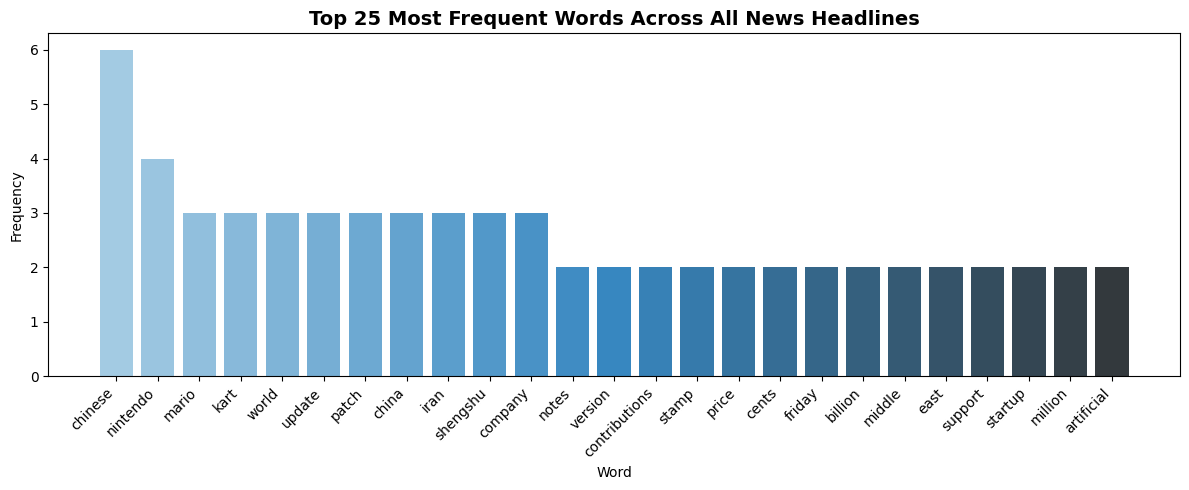

✅ Frequency chart displayed


In [ ]:
# ── Visualize: Top 25 words bar chart ───────────────────────────
top_words = freq_dist.most_common(25)
print(top_words)

top_words = freq_dist.most_common(25)
words, counts = zip(*top_words)
print(words, counts)

plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=sns.color_palette("Blues_d", 25))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Top 25 Most Frequent Words Across All News Headlines", fontsize=14, fontweight='bold')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("✅ Frequency chart displayed")

In [43]:
text_for_cloud = " ".join(all_tokens)
print(text_for_cloud)

mario kart world update patch notes nintendo everything mario kart world received version update nintendo patch notes nintendo back another update mario kart world bringing game version patch bug fixes additions nintendo addressed specif usps suspend pension contributions seeks cent stamp price hike politico approved regulators price class mail forever stamp rise cents cents despite suspension employer contributions effective friday current future retirees immediately impacted grossman risk postal service american publi billion middle east bet limits china support iran even china remains iran biggest diplomatic allies president jinping support islamic republic constrained vast trail chinese capital across gulf china ramped investment middle east wake chinese workers reported injured outside iran thousands working war zone conflict began chinese citizens stationed united arab emira chinese startup shengshu raises million advance artificial general intelligence founded early tsinghua uni

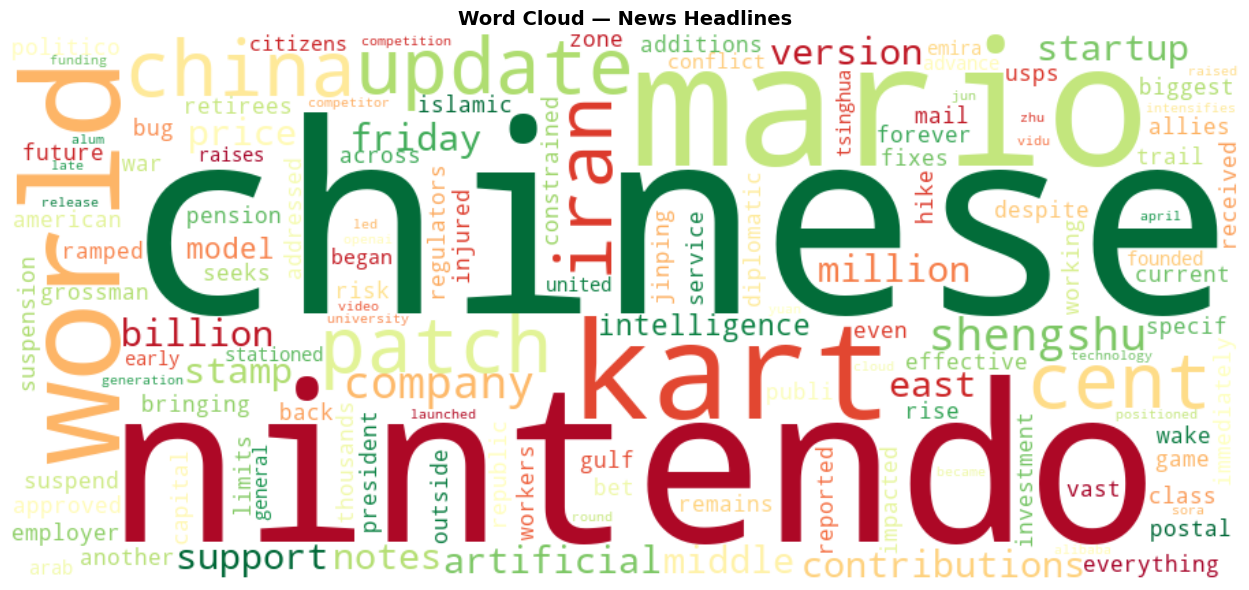

✅ Word cloud displayed


In [44]:
# ── Word Cloud ───────────────────────────────────────────────────

wc = WordCloud(
    width=900, height=400,
    background_color='white',
    colormap='RdYlGn',
    max_words=150,
    collocations=False
).generate(text_for_cloud)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — News Headlines", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Word cloud displayed")

In [45]:
tagged = nltk.pos_tag(df["tokens"][0])
print(tagged)

[('mario', 'NN'), ('kart', 'VB'), ('world', 'NN'), ('update', 'JJ'), ('patch', 'NN'), ('notes', 'NNS'), ('nintendo', 'IN'), ('everything', 'NN'), ('mario', 'NN'), ('kart', 'JJ'), ('world', 'NN'), ('received', 'VBD'), ('version', 'NN'), ('update', 'NN'), ('nintendo', 'JJ'), ('patch', 'NN'), ('notes', 'NNS'), ('nintendo', 'VBP'), ('back', 'RB'), ('another', 'DT'), ('update', 'NN'), ('mario', 'NN'), ('kart', 'NNP'), ('world', 'NN'), ('bringing', 'VBG'), ('game', 'NN'), ('version', 'NN'), ('patch', 'NN'), ('bug', 'NN'), ('fixes', 'JJ'), ('additions', 'NNS'), ('nintendo', 'VBP'), ('addressed', 'VBN'), ('specif', 'NN')]


In [47]:
# ──Part-of-Speech (POS) tagging  — identify noun-heavy vs action-heavy headlines ──
def pos_tag_summary(tokens: list) -> dict:
    """Return counts of nouns, verbs, adjectives in a token list."""
    tagged = nltk.pos_tag(tokens)
    pos_counts = {"NN": 0, "VB": 0, "JJ": 0}  # nouns, verbs, adjectives
    for _, tag in tagged:
        if tag.startswith("NN"): pos_counts["NN"] += 1
        elif tag.startswith("VB"): pos_counts["VB"] += 1
        elif tag.startswith("JJ"): pos_counts["JJ"] += 1
    return pos_counts

# Apply to a sample (POS tagging is slow on large datasets)
sample_df = df.head(50).copy()
sample_df["pos_tags"] = sample_df["tokens"].apply(pos_tag_summary)
sample_df["noun_count"] = sample_df["pos_tags"].apply(lambda x: x["NN"])
sample_df["verb_count"] = sample_df["pos_tags"].apply(lambda x: x["VB"])
sample_df["adj_count"]  = sample_df["pos_tags"].apply(lambda x: x["JJ"])

print("POS distribution (sample of 50 headlines):")
print(f"  Avg nouns per headline:      {sample_df['noun_count'].mean():.1f}")
print(f"  Avg verbs per headline:      {sample_df['verb_count'].mean():.1f}")
print(f"  Avg adjectives per headline: {sample_df['adj_count'].mean():.1f}")

print(sample_df.head())

POS distribution (sample of 50 headlines):
  Avg nouns per headline:      23.5
  Avg verbs per headline:      7.0
  Avg adjectives per headline: 9.2
                                               title  \
0  Mario Kart World 1.6.1 update out now, patch n...   
1  USPS to suspend pension contributions, seeks 4...   
2  Xi’s $270 Billion Middle East Bet Limits China...   
3  Chinese startup ShengShu raises $293 million t...   

                                         description                  source  \
0  Mario Kart World just received a new version 1...  Nintendoeverything.com   
1  If approved by regulators, the price of a firs...                Politico   
2  Even as China remains one of Iran’s biggest di...          Financial Post   
3  Founded in early 2023 by ​Tsinghua University ...      The Times of India   

                                                 url          published_at  \
0  https://nintendoeverything.com/mario-kart-worl...  2026-04-10T01:06:45Z   
1  https://ww

---
## 💬 Section 5 — Sentiment Analysis with Classical NLP

### Concept: Sentiment Analysis
We use **two complementary approaches**:

| Tool | Approach | Best For |
|---|---|---|
| **VADER** | Rule-based lexicon + social-media rules | Short texts, headlines, informal writing |
| **TextBlob** | Pattern-based with polarity/subjectivity | Slightly longer, more formal text |

**VADER scores:**
- `compound` — overall score from -1 (most negative) to +1 (most positive)
- `pos / neu / neg` — proportion of positive, neutral, negative words

**TextBlob scores:**
- `polarity` — -1 to +1 (negative to positive)
- `subjectivity` — 0 to 1 (objective to subjective)

VADER:    {'neg': 0.18, 'neu': 0.6, 'pos': 0.22, 'compound': 0.042}
TextBlob: polarity=0.05, subjectivity=0.52
```

---

## VADER scores

**`compound`** — the single summary score for the whole sentence, from -1.0 to +1.0.

It is calculated by combining all word scores, adjusting for grammar rules (negations, caps, punctuation), then normalising to fit between -1 and +1. This is the one number you use to label a sentence as Positive, Negative, or Neutral.
```
"The economy is growing steadily but unemployment remains a serious concern"
compound = +0.042  → Neutral  (just above zero — mixed message, slightly positive)

"Markets crash in worst single day since 2008"
compound = -0.74   → Negative

"Scientists announce a brilliant breakthrough cure"
compound = +0.81   → Positive
```

Rule of thumb: `>= +0.05` = Positive, `<= -0.05` = Negative, in between = Neutral.

---

**`pos`** — proportion of words in the sentence that carry positive meaning, from 0.0 to 1.0.

Not a sentiment score — a word *ratio*. It tells you how many of the total words were flagged as positive by the lexicon.
```
"The economy is growing steadily but unemployment remains a serious concern"
pos = 0.22  → 22% of words carry positive signal ("growing", "steadily")
```
```
"Absolutely wonderful, brilliant, fantastic news today"
pos = 0.75  → 75% of words are positive
```

---

**`neu`** — proportion of words that are emotionally neutral — carrying no positive or negative signal.

Most grammatical words (the, is, but, remains) and factual nouns (economy, unemployment) score as neutral. In news headlines this is usually the largest of the three scores.
```
"The economy is growing steadily but unemployment remains a serious concern"
neu = 0.60  → 60% of words are neutral ("the", "is", "but", "remains", "unemployment")
```
```
"Cat sits on mat"
neu = 1.0   → 100% neutral, zero emotional content
```

---

**`neg`** — proportion of words that carry negative meaning, from 0.0 to 1.0.

The mirror of `pos`. Note that `pos + neu + neg` always adds up to exactly 1.0 — they are shares of the same whole.
```
"The economy is growing steadily but unemployment remains a serious concern"
neg = 0.18  → 18% of words carry negative signal ("concern", "serious")

pos(0.22) + neu(0.60) + neg(0.18) = 1.0  ✓
```
```
"Devastating floods destroy entire village leaving families homeless"
neg = 0.71  → 71% of words are negative
```

---

## TextBlob scores

**`polarity`** — overall positive/negative direction of the sentence, from -1.0 to +1.0.

Conceptually similar to VADER's `compound` but calculated differently — TextBlob looks primarily at adjectives and adverbs and averages their dictionary scores. It does not apply the grammar adjustment rules that VADER does.
```
"The economy is growing steadily but unemployment remains a serious concern"
polarity = +0.05  → nearly neutral, slight positive lean
                    ("growing" and "steadily" are mildly positive,
                     "serious" and "concern" pull it back down)
```
```
"Terrible, catastrophic losses devastate investors"
polarity = -0.85  → strongly negative (adjectives dominate)

"A truly magnificent and inspiring discovery"
polarity = +0.90  → strongly positive (stacked positive adjectives)
```

---

**`subjectivity`** — how much the sentence is opinion vs fact, from 0.0 (fully objective) to 1.0 (fully subjective).

This score has no equivalent in VADER. It is TextBlob's unique contribution to this project. A sentence full of adjectives and personal judgement words scores high. A sentence of facts and numbers scores low.
```
"The economy is growing steadily but unemployment remains a serious concern"
subjectivity = 0.52  → moderate — "serious concern" is opinion,
                        "growing steadily" is borderline fact/opinion
```
```
"GDP grew by 2.4% in Q3 according to official figures"
subjectivity = 0.05  → nearly pure fact, no opinion words at all

"This is absolutely the worst government policy in living memory"
subjectivity = 0.95  → almost entirely opinion

In [48]:
# ── Initialise VADER ─────────────────────────────────────────────
vader = SentimentIntensityAnalyzer()


def vader_sentiment(text: str) -> dict:
    """Run VADER on raw (uncleaned) text — VADER works best on original text."""
    scores = vader.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = "Positive"
    elif compound <= -0.05:
        label = "Negative"
    else:
        label = "Neutral"
    return {"vader_compound": compound,
            "vader_pos": scores['pos'],
            "vader_neu": scores['neu'],
            "vader_neg": scores['neg'],
            "vader_label": label}


In [49]:
def textblob_sentiment(text: str) -> dict:
    """Run TextBlob on text."""
    blob = TextBlob(text)
    pol  = blob.sentiment.polarity
    subj = blob.sentiment.subjectivity
    if pol > 0.05:     label = "Positive"
    elif pol < -0.05:  label = "Negative"
    else:              label = "Neutral"
    return {"tb_polarity": pol, "tb_subjectivity": subj, "tb_label": label}

In [51]:
# ── Apply to every headline (use title + description for best results) ─
print("Running sentiment analysis...")
vader_results  = df["clean_text"].apply(vader_sentiment).apply(pd.Series)
textblob_results = df["clean_text"].apply(textblob_sentiment).apply(pd.Series)


print(vader_results)
print(textblob_results)

Running sentiment analysis...
   vader_compound  vader_pos  vader_neu  vader_neg vader_label
0          0.0000      0.000      1.000      0.000     Neutral
1          0.3612      0.090      0.842      0.067    Positive
2         -0.5106      0.081      0.796      0.123    Negative
3          0.7717      0.091      0.909      0.000    Positive
   tb_polarity  tb_subjectivity  tb_label
0    -0.031818         0.327273   Neutral
1     0.170000         0.331667  Positive
2     0.000000         0.150000   Neutral
3    -0.130000         0.413333  Negative


In [52]:
df = pd.concat([df, vader_results, textblob_results], axis=1)

In [53]:
df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,tokens,token_count,vader_compound,vader_pos,vader_neu,vader_neg,vader_label,tb_polarity,tb_subjectivity,tb_label
0,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,Nintendoeverything.com,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,technology,"Mario Kart World 1.6.1 update out now, patch n...",mario kart world update out now patch notes ni...,"[Mario Kart World, Nintendo Everything Mario K...",[],"[mario, kart, world, update, patch, notes, nin...",34,0.0000,0.000,1.000,0.000,Neutral,-0.031818,0.327273,Neutral
1,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",Politico,https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,business,"USPS to suspend pension contributions, seeks 4...",usps to suspend pension contributions seeks ce...,"[Politico If, Postal Service]",[USPS],"[usps, suspend, pension, contributions, seeks,...",37,0.3612,0.090,0.842,0.067,Positive,0.170000,0.331667,Positive
2,Xi’s $270 Billion Middle East Bet Limits China...,Even as China remains one of Iran’s biggest di...,Financial Post,https://financialpost.com/pmn/business-pmn/xis...,2026-04-10T04:58:55Z,kw:economy,Xi’s $270 Billion Middle East Bet Limits China...,xi s billion middle east bet limits china supp...,"[Billion Middle East Bet Limits China Support,...",[],"[billion, middle, east, bet, limits, china, su...",51,-0.5106,0.081,0.796,0.123,Negative,0.000000,0.150000,Neutral
3,Chinese startup ShengShu raises $293 million t...,Founded in early 2023 by ​Tsinghua University ...,The Times of India,https://economictimes.indiatimes.com/tech/fund...,2026-04-10T04:55:05Z,kw:artificial intelligence,Chinese startup ShengShu raises $293 million t...,chinese startup shengshu raises million to adv...,"[Tsinghua University, Zhu Jun, Alibaba Cloud]",[],"[chinese, startup, shengshu, raises, million, ...",53,0.7717,0.091,0.909,0.000,Positive,-0.130000,0.413333,Negative


In [54]:

# Consensus label (agree → use it, disagree → call it Neutral)
def consensus_label(row):
    if row["vader_label"] == row["tb_label"]:
        return row["vader_label"]
    # If one says Neutral and other says Positive/Negative, trust the non-neutral one
    if row["vader_label"] == "Neutral": return row["tb_label"]
    if row["tb_label"]    == "Neutral": return row["vader_label"]
    return "Neutral"  # conflicting non-neutral → call it Neutral

df["consensus_label"] = df.apply(consensus_label, axis=1)

print(f"\n✅ Sentiment analysis complete on {len(df)} articles")
print("\nConsensus label distribution:")
print(df["consensus_label"].value_counts())


✅ Sentiment analysis complete on 4 articles

Consensus label distribution:
consensus_label
Neutral     2
Positive    1
Negative    1
Name: count, dtype: int64


In [56]:
df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,...,token_count,vader_compound,vader_pos,vader_neu,vader_neg,vader_label,tb_polarity,tb_subjectivity,tb_label,consensus_label
0,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,Nintendoeverything.com,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,technology,"Mario Kart World 1.6.1 update out now, patch n...",mario kart world update out now patch notes ni...,"[Mario Kart World, Nintendo Everything Mario K...",[],...,34,0.0000,0.000,1.000,0.000,Neutral,-0.031818,0.327273,Neutral,Neutral
1,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",Politico,https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,business,"USPS to suspend pension contributions, seeks 4...",usps to suspend pension contributions seeks ce...,"[Politico If, Postal Service]",[USPS],...,37,0.3612,0.090,0.842,0.067,Positive,0.170000,0.331667,Positive,Positive
2,Xi’s $270 Billion Middle East Bet Limits China...,Even as China remains one of Iran’s biggest di...,Financial Post,https://financialpost.com/pmn/business-pmn/xis...,2026-04-10T04:58:55Z,kw:economy,Xi’s $270 Billion Middle East Bet Limits China...,xi s billion middle east bet limits china supp...,"[Billion Middle East Bet Limits China Support,...",[],...,51,-0.5106,0.081,0.796,0.123,Negative,0.000000,0.150000,Neutral,Negative
3,Chinese startup ShengShu raises $293 million t...,Founded in early 2023 by ​Tsinghua University ...,The Times of India,https://economictimes.indiatimes.com/tech/fund...,2026-04-10T04:55:05Z,kw:artificial intelligence,Chinese startup ShengShu raises $293 million t...,chinese startup shengshu raises million to adv...,"[Tsinghua University, Zhu Jun, Alibaba Cloud]",[],...,53,0.7717,0.091,0.909,0.000,Positive,-0.130000,0.413333,Negative,Neutral


In [57]:
# ── Show example headlines with their sentiment scores ───────────
cols = ["title", "category", "vader_compound", "tb_polarity", "tb_subjectivity", "consensus_label"]
display_df = df[cols].sort_values("vader_compound", ascending=False)

print("🟢 Top 5 Most POSITIVE headlines:")
for _, row in display_df.head(5).iterrows():
    print(f"  [{row['consensus_label']:8s} | score: {row['vader_compound']:+.2f}] {row['title'][:80]}")

print("\n🔴 Top 5 Most NEGATIVE headlines:")
for _, row in display_df.tail(5).iterrows():
    print(f"  [{row['consensus_label']:8s} | score: {row['vader_compound']:+.2f}] {row['title'][:80]}")

🟢 Top 5 Most POSITIVE headlines:
  [Neutral  | score: +0.77] Chinese startup ShengShu raises $293 million to advance artificial general intel
  [Positive | score: +0.36] USPS to suspend pension contributions, seeks 4-cent stamp price hike - Politico
  [Neutral  | score: +0.00] Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything
  [Negative | score: -0.51] Xi’s $270 Billion Middle East Bet Limits China Support for Iran

🔴 Top 5 Most NEGATIVE headlines:
  [Neutral  | score: +0.77] Chinese startup ShengShu raises $293 million to advance artificial general intel
  [Positive | score: +0.36] USPS to suspend pension contributions, seeks 4-cent stamp price hike - Politico
  [Neutral  | score: +0.00] Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything
  [Negative | score: -0.51] Xi’s $270 Billion Middle East Bet Limits China Support for Iran


In [58]:
# ── Visualize 1: Sentiment distribution by category ──────────────
COLOR_MAP = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}

cat_sentiment = df.groupby(["category", "consensus_label"]).size().unstack(fill_value=0)
print(cat_sentiment
      )
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100

consensus_label             Negative  Neutral  Positive
category                                               
business                           0        0         1
kw:artificial intelligence         0        1         0
kw:economy                         1        0         0
technology                         0        1         0


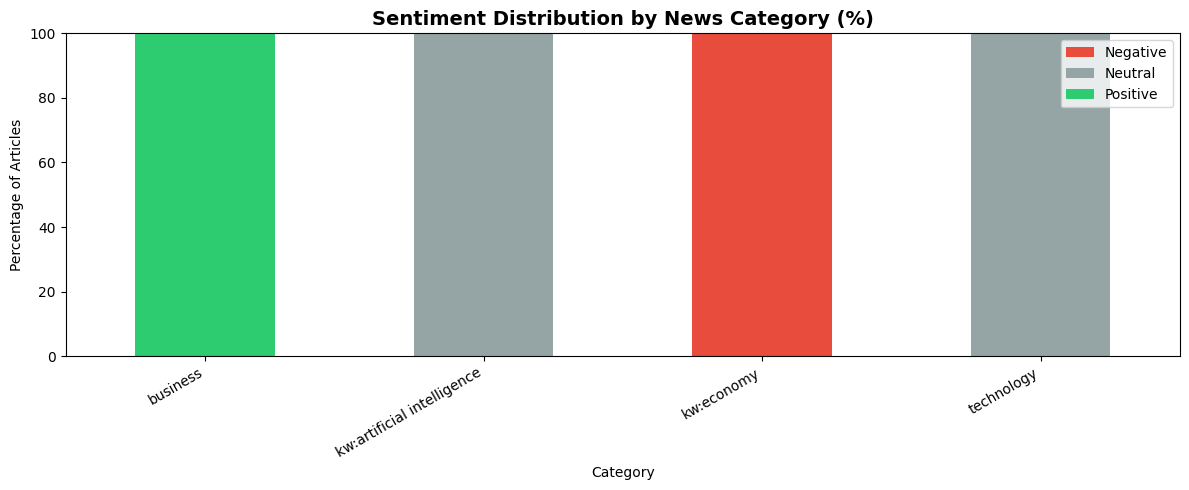

✅ Stacked bar chart displayed


In [59]:


ax = cat_sentiment_pct.plot(
    kind='bar', stacked=True, figsize=(12, 5),
    color=[COLOR_MAP.get(c, '#cccccc') for c in cat_sentiment_pct.columns]
)
plt.title("Sentiment Distribution by News Category (%)", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Percentage of Articles")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print("✅ Stacked bar chart displayed")

---
## 🕷️ Section 6 — Web Scraping with BeautifulSoup & Requests

### Concept: Web Scraping
NewsAPI only returns truncated article content. We can fetch the **full article text**  
by scraping the source page directly.

**Pipeline:**
1. `requests.get(url)` — download the HTML page
2. `BeautifulSoup(html, 'html.parser')` — parse the HTML tree
3. `.find_all('p')` — extract paragraph tags
4. Join and clean the text

**Responsible scraping rules:**
- Add `time.sleep()` between requests
- Set a User-Agent header (polite identification)
- Respect `robots.txt` (not covered here but important in production)

In [60]:
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
}

soup <!DOCTYPE html>
<html dir="ltr" lang="en"><head><link href="https://www.indiatoday.in/manifest.json" rel="manifest"/><meta content="#C04A4A" name="theme-color"/><link href="https://www.indiatoday.in/favicon.ico" rel="shortcut icon" type="image/vnd.microsoft.icon"/><title>Iran has lost track of mines it planted in Hormuz, reopening delayed: Report - India Today</title><meta charset="utf-8"/><meta content="width=device-width, minimum-scale=1, initial-scale=1.0, maximum-scale=5.0" name="viewport"/><link href="https://akm-img-a-in.tosshub.com/indiatoday/images/misc/IT-logo-180.png" rel="apple-touch-icon"/><link href="https://www.indiatoday.in/world/story/iran-lost-track-of-mines-it-planted-in-strait-of-hormuz-us-middle-east-war-2894654-2026-04-11" rel="canonical"/><meta content="US officials said that Iran's inability to locate and remove mines it deployed is delaying safe passage through the Strait of Hormuz, even as pressure mounts to restore normal shipping traffic." name="descript
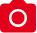

'Iran\'s inability to fully reopen the Strait of Hormuzstems from a basic problem that it cannot locate all the naval mines it deployed during the Middle East conflict and lacks the technical capability to remove them, US officials toldThe New York Times. The problem traces back to last month, when Iran began seeding the waterway with mines using small boats, soon after the United States and Israel launched their war against the Islamic nation. Even then, American officials noted the operation was neither fast nor efficient. Before any mines were placed, the disruption had already begun. On March 2, a senior Islamic Revolutionary Guards Corps official declared the strait closed andwarned that any vessel entering could be set \'ablaze\', according to state media. Shipping was rattled, and oil prices spiked across the globe. Once the mines were deployed, the impact deepened. Tanker movement dropped sharply, with the added threat of Iranian drone and missile strikes compounding the risk. 

In [65]:
def scrape_article_text(url: str, timeout: int = 8) -> str:
    """
    Scrape full article text from a given URL.
    Returns cleaned paragraph text or empty string on failure.
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=timeout)
        response.raise_for_status()                        # raise on 4xx/5xx

        soup = BeautifulSoup(response.text, 'html.parser')
        print('soup',soup)
        # ── Strategy 1: look for <article> tag (modern sites) ────
        article_tag = soup.find('article')
        print(article_tag, 'article_tag')
        if article_tag:
            paragraphs = article_tag.find_all('p')
        else:
            # ── Strategy 2: fall back to all <p> tags ────────────
            paragraphs = soup.find_all('p')
        print('paragraph', paragraphs)
        # Extract and join non-empty paragraph text
        text = ' '.join(
            p.get_text(strip=True)
            for p in paragraphs
            if len(p.get_text(strip=True)) > 40   # skip tiny/nav paragraphs
        )
        return text[:3000]   # cap at 3000 chars to keep things fast

    except Exception as e:
        return ""   # silently skip failed URLs
    
scrape_article_text('https://www.indiatoday.in/world/story/iran-lost-track-of-mines-it-planted-in-strait-of-hormuz-us-middle-east-war-2894654-2026-04-11')

In [66]:
df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,...,token_count,vader_compound,vader_pos,vader_neu,vader_neg,vader_label,tb_polarity,tb_subjectivity,tb_label,consensus_label
0,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,Nintendoeverything.com,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,technology,"Mario Kart World 1.6.1 update out now, patch n...",mario kart world update out now patch notes ni...,"[Mario Kart World, Nintendo Everything Mario K...",[],...,34,0.0000,0.000,1.000,0.000,Neutral,-0.031818,0.327273,Neutral,Neutral
1,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",Politico,https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,business,"USPS to suspend pension contributions, seeks 4...",usps to suspend pension contributions seeks ce...,"[Politico If, Postal Service]",[USPS],...,37,0.3612,0.090,0.842,0.067,Positive,0.170000,0.331667,Positive,Positive
2,Xi’s $270 Billion Middle East Bet Limits China...,Even as China remains one of Iran’s biggest di...,Financial Post,https://financialpost.com/pmn/business-pmn/xis...,2026-04-10T04:58:55Z,kw:economy,Xi’s $270 Billion Middle East Bet Limits China...,xi s billion middle east bet limits china supp...,"[Billion Middle East Bet Limits China Support,...",[],...,51,-0.5106,0.081,0.796,0.123,Negative,0.000000,0.150000,Neutral,Negative
3,Chinese startup ShengShu raises $293 million t...,Founded in early 2023 by ​Tsinghua University ...,The Times of India,https://economictimes.indiatimes.com/tech/fund...,2026-04-10T04:55:05Z,kw:artificial intelligence,Chinese startup ShengShu raises $293 million t...,chinese startup shengshu raises million to adv...,"[Tsinghua University, Zhu Jun, Alibaba Cloud]",[],...,53,0.7717,0.091,0.909,0.000,Positive,-0.130000,0.413333,Negative,Neutral


Scraping 5 full articles...
soup <!DOCTYPE HTML>
<html class="no-js" lang="en"><head><meta charset="utf-8"/><meta content="IE=edge" http-equiv="X-UA-Compatible"/><meta content="width=device-width, initial-scale=1" name="viewport"/><meta content="text/html; charset=utf-8" http-equiv="Content-Type"><link href="https://nintendoeverything.com/wp-content/cache/autoptimize/css/autoptimize_5565801cf817a542f90ad17c31b32fd8.css" media="all" rel="stylesheet"/><title>Mario Kart World 1.6.1 update out now, patch notes</title><link crossorigin="" href="https://securepubads.g.doubleclick.net/" rel="preconnect"/><link crossorigin="" href="https://cdn.consentmanager.mgr.consensu.org/" rel="preconnect"/><link crossorigin="" href="https://live.primis.tech" rel="preconnect"/><link as="script" href="https://00917082-71e9-498e-8343-00c3df06b798.edge.permutive.app/00917082-71e9-498e-8343-00c3df06b798-web.js" rel="preload"/><link as="script" href="https://sb.scorecardresearch.com/cs/25110922/beacon.js" rel="
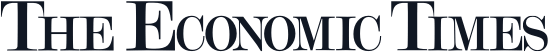

In [67]:




# ── Scrape a small sample (5 articles) to demonstrate ────────────
# (Scraping all 100+ would be slow — use a subset for the lab)
SCRAPE_SAMPLE = 5
scrape_sample = df[df["url"].str.startswith("http")].head(SCRAPE_SAMPLE).copy()

print(f"Scraping {SCRAPE_SAMPLE} full articles...")
scraped_texts = []
for i, (idx, row) in enumerate(scrape_sample.iterrows()):
    text = scrape_article_text(row["url"])
    word_count = len(text.split()) if text else 0
    scraped_texts.append(text)
    status = "✅" if text else "⚠️ "
    print(f"  {status} [{i+1}/{SCRAPE_SAMPLE}] {row['source']:20s} → {word_count:4d} words")
    time.sleep(1)   # be polite — 1 second between requests

scrape_sample["scraped_text"] = scraped_texts
print("\nDone!")

In [68]:
scrape_sample.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,...,vader_compound,vader_pos,vader_neu,vader_neg,vader_label,tb_polarity,tb_subjectivity,tb_label,consensus_label,scraped_text
0,"Mario Kart World 1.6.1 update out now, patch n...",Mario Kart World just received a new version 1...,Nintendoeverything.com,https://nintendoeverything.com/mario-kart-worl...,2026-04-10T01:06:45Z,technology,"Mario Kart World 1.6.1 update out now, patch n...",mario kart world update out now patch notes ni...,"[Mario Kart World, Nintendo Everything Mario K...",[],...,0.0000,0.000,1.000,0.000,Neutral,-0.031818,0.327273,Neutral,Neutral,Nintendo is back with another update for Mario...
1,"USPS to suspend pension contributions, seeks 4...","If approved by regulators, the price of a firs...",Politico,https://www.politico.com/news/2026/04/09/usps-...,2026-04-10T01:00:00Z,business,"USPS to suspend pension contributions, seeks 4...",usps to suspend pension contributions seeks ce...,"[Politico If, Postal Service]",[USPS],...,0.3612,0.090,0.842,0.067,Positive,0.170000,0.331667,Positive,Positive,
2,Xi’s $270 Billion Middle East Bet Limits China...,Even as China remains one of Iran’s biggest di...,Financial Post,https://financialpost.com/pmn/business-pmn/xis...,2026-04-10T04:58:55Z,kw:economy,Xi’s $270 Billion Middle East Bet Limits China...,xi s billion middle east bet limits china supp...,"[Billion Middle East Bet Limits China Support,...",[],...,-0.5106,0.081,0.796,0.123,Negative,0.000000,0.150000,Neutral,Negative,Even as China remains one of Iran’s biggest di...
3,Chinese startup ShengShu raises $293 million t...,Founded in early 2023 by ​Tsinghua University ...,The Times of India,https://economictimes.indiatimes.com/tech/fund...,2026-04-10T04:55:05Z,kw:artificial intelligence,Chinese startup ShengShu raises $293 million t...,chinese startup shengshu raises million to adv...,"[Tsinghua University, Zhu Jun, Alibaba Cloud]",[],...,0.7717,0.091,0.909,0.000,Positive,-0.130000,0.413333,Negative,Neutral,"(Catch all theTechnology News News, andLatest ..."


In [69]:
# ── Inspect what was scraped ─────────────────────────────────────
for _, row in scrape_sample.iterrows():
    if row["scraped_text"]:
        print(f"\n{'='*60}")
        print(f"SOURCE  : {row['source']}")
        print(f"HEADLINE: {row['title'][:80]}")
        print(f"SCRAPED TEXT PREVIEW (first 300 chars):")
        print(f"  {row['scraped_text'][:300]}...")
        break   # show just one example


SOURCE  : Nintendoeverything.com
HEADLINE: Mario Kart World 1.6.1 update out now, patch notes - Nintendo Everything
SCRAPED TEXT PREVIEW (first 300 chars):
  Nintendo is back with another update for Mario Kart World, bringing the game up to version 1.6.1.This patch is about bug fixes, so there aren’t any new additions here. Nintendo addressed two specific issues this time around.The full rundown is as follows:Mario Kart World version 1.6.1 update patch n...


In [70]:
# ── Analyse scraped text with BeautifulSoup metadata extraction ──
def extract_page_metadata(url: str) -> dict:
    """
    Extract metadata (og:title, og:description, keywords) from a page.
    Demonstrates BeautifulSoup meta tag parsing.
    """
    try:
        response = requests.get(url, headers=HEADERS, timeout=8)
        soup = BeautifulSoup(response.text, 'html.parser')

        def get_meta(prop):
            tag = soup.find('meta', property=prop) or soup.find('meta', attrs={'name': prop})
            return tag['content'] if tag and tag.get('content') else None

        return {
            "og_title":       get_meta('og:title'),
            "og_description": get_meta('og:description'),
            "meta_keywords":  get_meta('keywords'),
            "h1_tags":        [h.get_text(strip=True) for h in soup.find_all('h1')][:3]
        }
    except Exception:
        return {}


# Demo on first article
sample_url = df[df["url"].str.startswith("http")]["url"].iloc[0]
meta = extract_page_metadata(sample_url)
print("Page metadata extracted via BeautifulSoup:")
for key, val in meta.items():
    print(f"  {key:20s}: {str(val)[:80]}")

Page metadata extracted via BeautifulSoup:
  og_title            : Mario Kart World 1.6.1 update out now, patch notes
  og_description      : Mario Kart World just received a new version 1.6.1 update from Nintendo, and you
  meta_keywords       : None
  h1_tags             : ['Mario Kart World 1.6.1 update out now, patch notes']


---
## 📊 Section 7 — Full Dashboard: Collecting & Analyzing Web Data for NLP

This section brings everything together into a **multi-panel sentiment dashboard**  
that answers questions like:
- Which news category is most negative today?
- Which sources publish the most biased (subjective) headlines?
- What named entities appear most in negative news?
- How do sentiment scores distribute across the dataset?

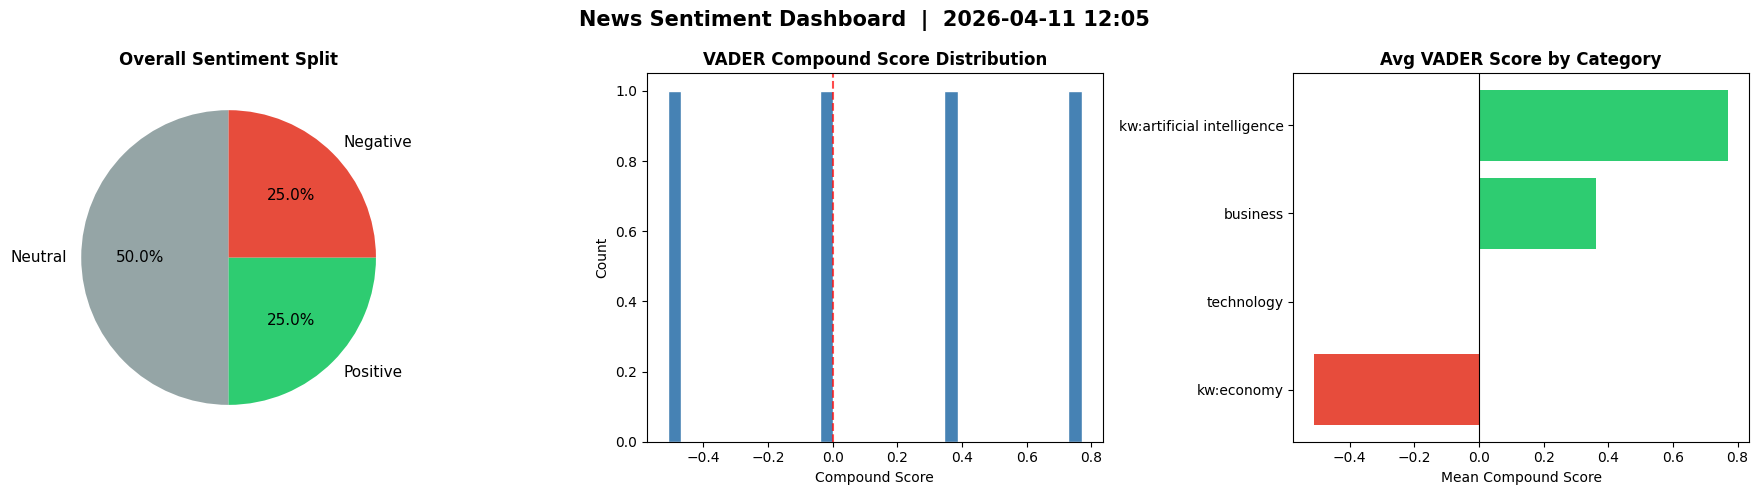

✅ Dashboard Panel 1 displayed


In [71]:
# ── Dashboard Panel 1: Sentiment Overview Pie ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"News Sentiment Dashboard  |  {datetime.now().strftime('%Y-%m-%d %H:%M')}",
             fontsize=15, fontweight='bold')

# Panel 1 — Overall pie
counts = df["consensus_label"].value_counts()
axes[0].pie(
    counts.values,
    labels=counts.index,
    colors=[COLOR_MAP[l] for l in counts.index],
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
axes[0].set_title("Overall Sentiment Split", fontweight='bold')

# Panel 2 — VADER compound distribution histogram
axes[1].hist(df["vader_compound"], bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title("VADER Compound Score Distribution", fontweight='bold')
axes[1].set_xlabel("Compound Score")
axes[1].set_ylabel("Count")

# Panel 3 — Average sentiment per category
cat_avg = df.groupby('category')['vader_compound'].mean().sort_values()
colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in cat_avg.values]
axes[2].barh(cat_avg.index, cat_avg.values, color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title("Avg VADER Score by Category", fontweight='bold')
axes[2].set_xlabel("Mean Compound Score")

plt.tight_layout()
plt.show()
print("✅ Dashboard Panel 1 displayed")

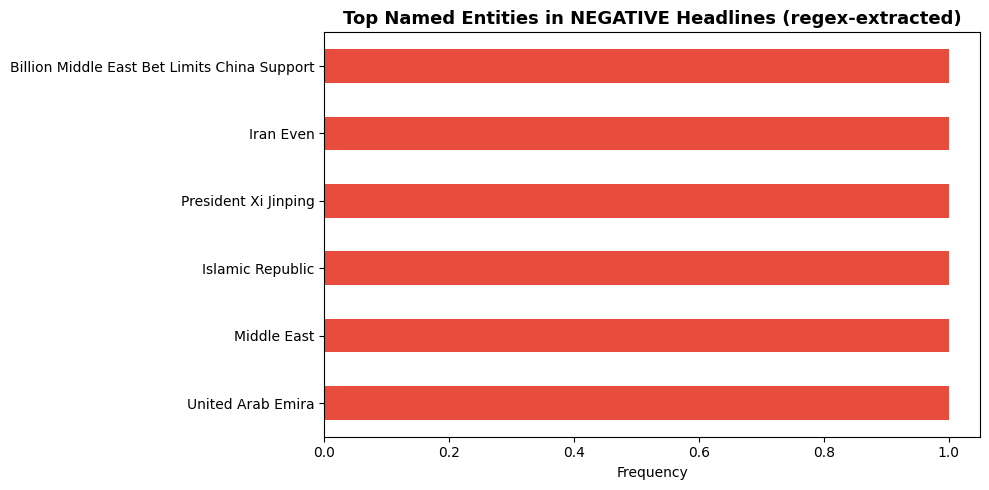

✅ Named entity chart displayed


In [72]:
# ── Dashboard Panel 3: Named entity frequency in negative news ───
negative_articles = df[df["consensus_label"] == "Negative"]
neg_entities = [e for entities in negative_articles["proper_nouns"] for e in entities]

if neg_entities:
    neg_freq = pd.Series(neg_entities).value_counts().head(20)

    plt.figure(figsize=(10, 5))
    neg_freq.plot(kind='barh', color='#e74c3c')
    plt.title("Top Named Entities in NEGATIVE Headlines (regex-extracted)",
              fontsize=13, fontweight='bold')
    plt.xlabel("Frequency")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print("✅ Named entity chart displayed")
else:
    print("No named entities found in negative articles (check your data).")

---
## 📋 Section 8 — Summary Report

Export findings to a clean tabular summary.

In [73]:
# ── Print final summary ──────────────────────────────────────────
print("="*60)
print(" NEWS SENTIMENT DASHBOARD — SUMMARY REPORT")
print(f" Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)
print(f" Total articles analysed : {len(df)}")
print(f" Categories covered      : {', '.join(df['category'].unique())}")
print(f" Unique sources          : {df['source'].nunique()}")
print()
print(" SENTIMENT BREAKDOWN:")
for label, count in df['consensus_label'].value_counts().items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 3)
    print(f"   {label:10s} {bar:30s} {count:4d} ({pct:.1f}%)")
print()
print(" MOST POSITIVE CATEGORIES:")
cat_avg = df.groupby('category')['vader_compound'].mean().sort_values(ascending=False)
for cat, score in cat_avg.items():
    emoji = '🟢' if score > 0.05 else ('🔴' if score < -0.05 else '⚪')
    print(f"   {emoji} {cat:20s} score: {score:+.3f}")
print()
print(" TOP KEYWORDS IN HEADLINES:")
for word, count in freq_dist.most_common(10):
    print(f"   {word:20s} {count} mentions")
print("="*60)

 NEWS SENTIMENT DASHBOARD — SUMMARY REPORT
 Generated: 2026-04-11 12:06:12
 Total articles analysed : 4
 Categories covered      : technology, business, kw:economy, kw:artificial intelligence
 Unique sources          : 4

 SENTIMENT BREAKDOWN:
   Neutral    ████████████████                  2 (50.0%)
   Positive   ████████                          1 (25.0%)
   Negative   ████████                          1 (25.0%)

 MOST POSITIVE CATEGORIES:
   🟢 kw:artificial intelligence score: +0.772
   🟢 business             score: +0.361
   ⚪ technology           score: +0.000
   🔴 kw:economy           score: -0.511

 TOP KEYWORDS IN HEADLINES:
   chinese              6 mentions
   nintendo             4 mentions
   mario                3 mentions
   kart                 3 mentions
   world                3 mentions
   update               3 mentions
   patch                3 mentions
   china                3 mentions
   iran                 3 mentions
   shengshu             3 mentions


In [74]:
# ── Export final DataFrame to CSV ────────────────────────────────
output_cols = [
    'title', 'source', 'category', 'published_at',
    'vader_compound', 'vader_label',
    'tb_polarity', 'tb_subjectivity', 'tb_label',
    'consensus_label', 'token_count', 'url'
]
df[output_cols].to_csv('news_sentiment_results.csv', index=False)
print("✅ Results saved to news_sentiment_results.csv")
print(f"   Shape: {df[output_cols].shape}")
df[output_cols].head()

✅ Results saved to news_sentiment_results.csv
   Shape: (4, 12)


,title,source,category,published_at,vader_compound,vader_label,tb_polarity,tb_subjectivity,tb_label,consensus_label,token_count,url
0,"Mario Kart World 1.6.1 update out now, patch n...",Nintendoeverything.com,technology,2026-04-10T01:06:45Z,0.0000,Neutral,-0.031818,0.327273,Neutral,Neutral,34,https://nintendoeverything.com/mario-kart-worl...
1,"USPS to suspend pension contributions, seeks 4...",Politico,business,2026-04-10T01:00:00Z,0.3612,Positive,0.170000,0.331667,Positive,Positive,37,https://www.politico.com/news/2026/04/09/usps-...
2,Xi’s $270 Billion Middle East Bet Limits China...,Financial Post,kw:economy,2026-04-10T04:58:55Z,-0.5106,Negative,0.000000,0.150000,Neutral,Negative,51,https://financialpost.com/pmn/business-pmn/xis...
3,Chinese startup ShengShu raises $293 million t...,The Times of India,kw:artificial intelligence,2026-04-10T04:55:05Z,0.7717,Positive,-0.130000,0.413333,Negative,Neutral,53,https://economictimes.indiatimes.com/tech/fund...


---
## 🚀 Section 9 — Extensions & Challenges

Once you've completed the above, try these extensions:

### 🔵 Beginner
1. Change `CATEGORIES` to include different news categories
2. Change `COUNTRY` to `in` (India), `gb` (UK), etc. and compare sentiment
3. Add more stopwords to the `STOP_WORDS` set and see how the word cloud changes

### 🟡 Intermediate
4. Add a **time series plot**: group articles by `published_at` hour and plot sentiment over time
5. Build a **Source Bias Meter**: rank sources by their average subjectivity score
6. Compare VADER vs TextBlob agreement rate — when do they disagree?

### 🔴 Advanced
7. Replace VADER with a **HuggingFace transformer** (`distilbert-base-uncased-finetuned-sst-2-english`) — does it give better results?
8. Use **spaCy** for proper Named Entity Recognition instead of the regex heuristic
9. Schedule the notebook to run every hour and log sentiment trends to a SQLite database
10. Build a **Streamlit app** from this notebook for a live interactive dashboard

---

## 📖 References
- NewsAPI docs: https://newsapi.org/docs
- VADER paper: https://ojs.aaai.org/index.php/ICWSM/article/view/14550
- TextBlob docs: https://textblob.readthedocs.io
- BeautifulSoup docs: https://www.crummy.com/software/BeautifulSoup/bs4/doc/
- NLTK book (free): https://www.nltk.org/book/